In [ ]:
! pip -q install btester requests tqdm joblib yfinance quantstats==0.0.59

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Workaround for QuantStats compatibility with newer IPython versions
import IPython
if hasattr(IPython, 'get_ipython'):
    ipython = IPython.get_ipython()
    if ipython and not hasattr(ipython, 'magic'):
        # Add magic method for backward compatibility
        ipython.magic = lambda x: ipython.run_line_magic(*x.split(' ', 1))

In [3]:
import yfinance as yf
import pandas as pd
import requests

start = '2006-01-01'
end = '2024-01-01'

assets = 'nasdaq100'
benchmark = 'NQ=F'

ldf = pd.read_html(requests.get(f'https://www.slickcharts.com/{assets}', headers={'User-agent': 'Mozilla/5.0'}).text)
symbols = [x.replace('.','-') for x in ldf[0]['Symbol'] if isinstance(x, str)]
downloads = yf.download([*symbols, benchmark], start, end, group_by='ticker')

data = downloads[symbols]
benchmark = downloads[benchmark]['Close']

[*********************100%***********************]  102 of 102 completed


In [4]:
from btester import Strategy

def UpBreakout(ser: pd.Series, period: int):
    return (ser.rolling(period).max().diff() > 0).values

def DownBreakout(ser: pd.Series, period: int):
    return (ser.rolling(period).min().diff() < 0).values

class BreakoutStrategy(Strategy):
    buy_at_once_size = .02 # 2%

    def init(self, buy_period: int, sell_period: int):
        self.buy_signal = {}
        self.sell_signal = {}

        for symbol in self.symbols:
            self.buy_signal[symbol] = UpBreakout(self.data[(symbol,'Close')], buy_period)
            self.sell_signal[symbol] = DownBreakout(self.data[(symbol,'Close')], sell_period)

    def next(self, i, record):
        for symbol in self.symbols:
            if self.buy_signal[symbol][i-1]:
                self.open(symbol=symbol, price=record[(symbol,'Open')], size=self.positionSize(record[(symbol,'Open')]))

        for position in self.open_positions[:]:
            if self.sell_signal[position.symbol][i-1]:
                self.close(position=position, price=record[(position.symbol,'Open')])

    def positionSize(self, price: float):
        return round((self.cash + self.assets_value) / price * self.buy_at_once_size) if price > 0 else 0

In [5]:
from btester import Backtest
backtest = Backtest(BreakoutStrategy, data, commission=.001, cash=1e6)

In [6]:
import quantstats as qs
from itertools import product
from joblib import Parallel, delayed
from tqdm.auto import tqdm

parameters = ['Buy period','Sell period']
values = [[5, 10, 20, 50, 75, 100, 150, 200], [5, 10, 20, 50, 75, 100, 150, 200]]

def run(v):
    result = backtest.run(*v)
    returns = result.returns
    return [*v, returns.iloc[0], returns.iloc[-1], qs.stats.max_drawdown(returns) * 100, qs.stats.cagr(returns) * 100, qs.stats.sharpe(returns)]

optimization_results = Parallel(n_jobs=-1)(delayed(run)(v) for v in tqdm(list(product(*values))))
optimization_results = pd.DataFrame(optimization_results, columns=[*parameters,'Initial Capital','Cumulative Return','Max Drawdown (%)','CAGR (%)','Sharpe Ratio'])
optimization_results.set_index([*parameters], inplace=True)

100%|██████████| 64/64 [00:04<00:00, 12.83it/s] 


In [7]:
optimization_results_sorted = optimization_results.sort_values('Sharpe Ratio', ascending=False)
optimization_results_sorted

,,Initial Capital,Cumulative Return,Max Drawdown (%),CAGR (%),Sharpe Ratio
Buy period,Sell period,,,,,
5,50,1.002372e+06,5.297565e+07,-52.148841,24.663530,1.132666
20,50,1.001727e+06,3.911738e+07,-36.863327,22.584857,1.101203
10,50,1.001991e+06,4.141447e+07,-49.780582,22.972344,1.098596
5,100,1.002372e+06,5.358002e+07,-57.017672,24.742132,1.060897
10,100,1.001991e+06,4.303453e+07,-50.464841,23.234817,1.049471
...,...,...,...,...,...,...
200,10,1.000000e+06,2.275413e+06,-38.751450,4.674213,0.396016
75,5,1.000000e+06,2.015565e+06,-38.365052,3.971308,0.382283
100,5,1.000000e+06,1.765793e+06,-36.980158,3.209806,0.328340


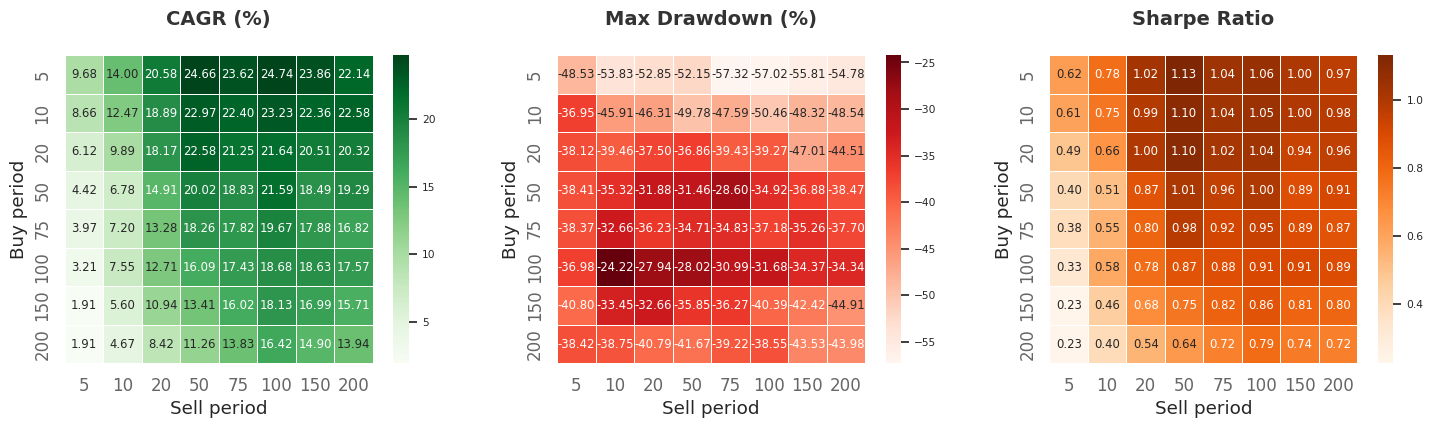

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(18,4))

ax[0].set_title('CAGR (%)\n', fontsize=14, fontweight='bold')
ax[1].set_title('Max Drawdown (%)\n', fontsize=14, fontweight='bold')
ax[2].set_title('Sharpe Ratio\n', fontsize=14, fontweight='bold')

reshape = lambda d: pd.DataFrame(d.values.reshape(len(d.index.levels[0]), len(d.index.levels[1])), d.index.levels[0], d.index.levels[1])

sns.set(font_scale=.7)
sns.heatmap(reshape(optimization_results['CAGR (%)']), ax=ax[0], annot=True, fmt='.2f', linewidth=.5, square=True, cmap='Greens')
sns.heatmap(reshape(optimization_results['Max Drawdown (%)']), ax=ax[1], annot=True, fmt='.2f', linewidth=.5, square=True, cmap='Reds')
sns.heatmap(reshape(optimization_results['Sharpe Ratio']), ax=ax[2], annot=True, fmt='.2f', linewidth=.5, square=True, cmap='Oranges')

plt.show()

In [9]:
best_params = optimization_results_sorted.index[0]
best_params

(np.int64(5), np.int64(50))

In [10]:
result = backtest.run(*best_params)

In [11]:
import quantstats as qs
qs.reports.metrics(result.returns, benchmark)

                    Strategy    Benchmark
------------------  ----------  -----------
Start Period        2006-01-03  2006-01-03
End Period          2023-12-29  2023-12-29
Risk-Free Rate      0.0%        0.0%
Time in Market      100.0%      100.0%

Cumulative Return   5,185.03%   905.52%
CAGR﹪              24.66%      13.68%

Sharpe              1.13        0.69
Prob. Sharpe Ratio  100.0%      99.82%
Sortino             1.61        0.97
Sortino/√2          1.14        0.69
Omega               1.22        1.22

Max Drawdown        -52.15%     -53.85%
Longest DD Days     769         1161

Gain/Pain Ratio     0.22        0.14
Gain/Pain (1M)      1.5         0.83

Payoff Ratio        0.9         0.87
Profit Factor       1.22        1.14
Common Sense Ratio  1.14        1.04
CPC Index           0.62        0.55
Tail Ratio          0.94        0.92
Outlier Win Ratio   3.78        3.96
Outlier Loss Ratio  3.76        3.87

MTD                 4.74%       6.49%
3M                  9.79%       1

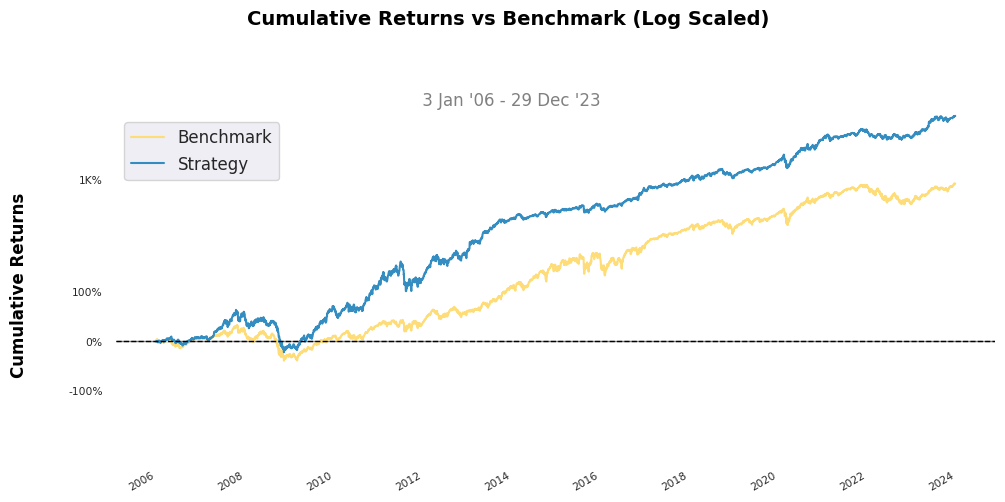

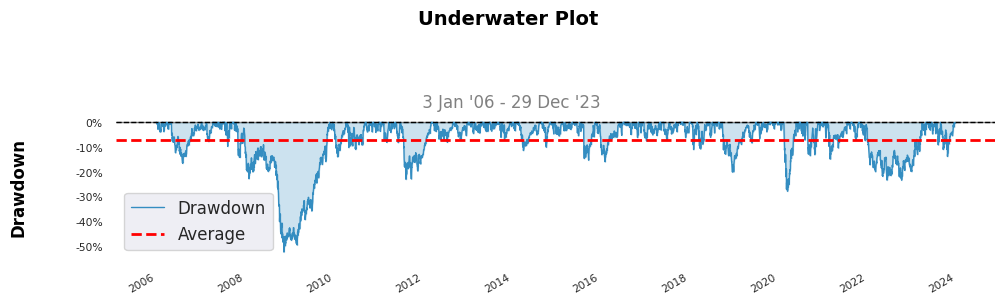

In [12]:
qs.plots.log_returns(result.returns, benchmark, fontname='sans-serif')
qs.plots.drawdown(result.returns, figsize=(10,3), fontname='sans-serif')

In [13]:
import pandas as pd

periodic_returns = result.returns.pct_change()

# Compound periodic returns into monthly returns
monthly_returns = (1 + periodic_returns).resample("ME").prod() - 1
monthly_grid = (
    monthly_returns.to_frame("Monthly Returns")
    .assign(year=lambda df: df.index.year, month=lambda df: df.index.month)
    .pivot(index="year", columns="month", values="Monthly Returns")
    .reindex(columns=range(1, 13))
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_grid.columns = month_labels

# Add yearly compounded return as the last column
yearly_returns = (1 + periodic_returns).resample("YE").prod() - 1
monthly_grid["Year"] = yearly_returns.values

# Human-readable format like 5.35%
monthly_grid_pct = monthly_grid.map(lambda x: f"{x:.2%}" if pd.notna(x) else "-")
monthly_grid_pct

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Year
year,,,,,,,,,,,,,
2006,1.46%,-0.55%,3.55%,1.73%,-3.93%,0.60%,-5.95%,-0.39%,4.73%,4.69%,1.51%,-0.16%,6.92%
2007,1.34%,-2.38%,0.39%,10.58%,7.31%,1.44%,8.19%,1.64%,8.18%,6.13%,-7.16%,4.46%,46.37%
2008,-14.68%,0.40%,2.48%,3.91%,2.47%,-9.03%,3.87%,0.36%,-9.74%,-23.63%,-7.39%,3.01%,-41.71%
2009,-3.46%,-0.81%,7.96%,15.64%,-0.86%,3.69%,9.57%,6.04%,7.84%,-1.85%,17.17%,3.75%,83.73%
2010,-10.29%,2.87%,6.04%,4.27%,-2.32%,-4.62%,2.46%,-0.44%,14.38%,5.07%,8.69%,-3.00%,22.87%
2011,9.14%,1.70%,4.77%,-0.06%,5.81%,-1.69%,-1.79%,-11.00%,-4.21%,7.54%,-0.06%,0.10%,8.90%
2012,6.52%,5.80%,6.36%,1.36%,-4.05%,0.31%,-0.46%,2.85%,3.03%,-2.64%,2.70%,-1.11%,21.96%
2013,8.51%,1.48%,1.63%,4.89%,12.12%,1.27%,7.30%,6.50%,9.30%,-2.65%,1.09%,4.56%,71.30%
2014,0.94%,6.59%,-4.74%,-2.35%,3.99%,1.96%,-1.63%,7.45%,-0.10%,0.26%,4.72%,-0.17%,17.44%


In [14]:
trades = pd.DataFrame(result.trades)
trades

,symbol,open_date,close_date,open_price,close_price,position_size,leverage,profit_loss,change_pct,trade_commission,cumulative_return
0,MSFT,2006-01-03,2006-05-04,18.261980,16.299503,1095,1.0,-2148.912206,-10.746244,37.844823,9.978132e+05
1,ADP,2006-01-03,2006-05-04,22.708409,21.496932,881,1.0,-1067.310813,-5.334925,38.944906,9.967070e+05
2,MSFT,2006-01-11,2006-05-04,18.790719,16.299503,1072,1.0,-2670.583350,-13.257693,37.616717,9.939988e+05
3,MSFT,2006-01-12,2006-05-04,18.957678,16.299503,1068,1.0,-2838.931110,-14.021629,37.654669,9.911222e+05
4,CSCO,2006-01-03,2006-05-12,11.135753,13.044556,1796,1.0,3428.209944,17.141211,43.427834,9.945070e+05
...,...,...,...,...,...,...,...,...,...,...,...
2155,GEHC,2023-09-26,2023-10-30,65.916220,63.306298,14455,1.0,-37726.424580,-3.959454,1867.911507,4.368905e+07
2156,VRTX,2023-03-14,2023-11-17,293.809998,346.260010,2296,1.0,120425.228027,17.851677,1469.600737,4.380801e+07
2157,WMT,2023-04-21,2023-11-20,49.034109,50.559056,15147,1.0,23098.365834,3.109971,1508.537675,4.382960e+07
2158,WMT,2023-10-25,2023-11-20,53.035969,50.559056,18322,1.0,-45381.994595,-4.670251,1898.068040,4.378232e+07


In [15]:
open_positions = pd.DataFrame(result.open_positions)
open_positions

,symbol,open_date,last_date,open_price,last_price,position_size,leverage,profit_loss,change_pct,current_value
0,META,2022-12-30,2023-12-29,117.340348,351.504639,5279,1.0,1.236153e+06,199.559908,1.855593e+06
1,META,2023-01-05,2023-12-29,125.255054,351.504639,4905,1.0,1.109754e+06,180.631102,1.724130e+06
2,MU,2023-01-05,2023-12-29,53.117494,84.699394,11565,1.0,3.652447e+05,59.456683,9.795485e+05
3,CRWD,2023-02-28,2023-12-29,120.199997,255.320007,5677,1.0,7.670763e+05,112.412657,1.449452e+06
4,COST,2023-08-11,2023-12-29,539.132641,651.950073,1797,1.0,2.027329e+05,20.925728,1.171554e+06
5,STX,2023-09-25,2023-12-29,61.432409,81.363228,15403,1.0,3.069944e+05,32.443491,1.253238e+06
6,CEG,2023-09-26,2023-12-29,109.870130,115.282784,8673,1.0,4.694394e+04,4.926410,9.998476e+05
7,PLTR,2023-09-28,2023-12-29,15.140000,17.170000,62975,1.0,1.278392e+05,13.408188,1.081281e+06
8,NFLX,2023-10-20,2023-12-29,40.563000,48.688000,23566,1.0,1.914738e+05,20.030570,1.147381e+06
9,NFLX,2023-10-25,2023-12-29,41.602001,48.688000,23357,1.0,1.655077e+05,17.032831,1.137206e+06
